# Exercises XP Gold: Student Notebook



## Exercise 1: Analyzing Confusion Matrix

### Instructions
Imagine you have a dataset for a binary classification problem, such as email spam detection, where emails are classified as either 'Spam' or 'Not Spam'. You are provided with the confusion matrix results of a classifier.

1. Define in your own words what True Positives, True Negatives, False Positives, and False Negatives mean in the context of this email spam detection problem.
2. Given a confusion matrix with specific values for TP, TN, FP, FN, calculate the Accuracy, Precision, Recall, and F1-Score.
3. Discuss how the classifier's performance would change with a higher number of False Positives compared to False Negatives, and vice versa.

### Guidance
You will start by writing complete sentences that define True Positives, True Negatives, False Positives, and False Negatives using the spam example.
You will then run the prefilled code to enter TP, TN, FP, and FN and compute the four metrics.
You will also generate a calculation sheet that tabulates the metrics so you can export or present the results.
You will finish by writing a paragraph that explains how increasing False Positives versus increasing False Negatives changes the behavior and implications of the classifier.

### Definitions of Confusion Matrix Terms in Email Spam Detection Context

**True Positives (TP):** These are emails that the classifier correctly identified as spam when they actually are spam. The model made the right decision by flagging these malicious emails and preventing them from reaching the user's inbox.

**True Negatives (TN):** These are legitimate emails that the classifier correctly identified as not spam. The model made the right decision by allowing these genuine emails to pass through to the user's inbox without interference.

**False Positives (FP):** These are legitimate emails that the classifier incorrectly identified as spam. The model made an error by flagging genuine emails as spam, potentially causing users to miss important communications by sending them to the spam folder.

**False Negatives (FN):** These are spam emails that the classifier incorrectly identified as legitimate. The model made an error by allowing spam emails to reach the user's inbox, exposing users to potentially harmful or unwanted content.

In [1]:


TP = 50   
TN = 920  
FP = 30   
FN = 20   

total = TP + TN + FP + FN
accuracy  = (TP + TN) / total if total else 0.0
precision = TP / (TP + FP) if (TP + FP) else 0.0
recall    = TP / (TP + FN) if (TP + FN) else 0.0
f1_score  = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

print("Confusion Matrix Values:")
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"Total samples: {total}")
print("\nCalculated Metrics:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1_score, 4))

Confusion Matrix Values:
True Positives (TP): 50
True Negatives (TN): 920
False Positives (FP): 30
False Negatives (FN): 20
Total samples: 1020

Calculated Metrics:
Accuracy: 0.951
Precision: 0.625
Recall: 0.7143
F1-Score: 0.6667


In [2]:
import pandas as pd
import os

calc_sheet = pd.DataFrame([{
    "TP": TP, "TN": TN, "FP": FP, "FN": FN,
    "Accuracy": round(accuracy, 4), 
    "Precision": round(precision, 4), 
    "Recall": round(recall, 4), 
    "F1-Score": round(f1_score, 4)
}])

print("Calculation Sheet:")
print(calc_sheet)

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, "confusion_metrics_sheet.csv")
calc_sheet.to_csv(csv_path, index=False)
print(f"\nSaved CSV to: {csv_path}")

print("\nMetrics Interpretation:")
print(f"• Accuracy ({accuracy:.1%}): Overall correctness of the classifier")
print(f"• Precision ({precision:.1%}): Of emails flagged as spam, {precision:.1%} were actually spam")
print(f"• Recall ({recall:.1%}): Of actual spam emails, {recall:.1%} were correctly identified")
print(f"• F1-Score ({f1_score:.3f}): Harmonic mean balancing precision and recall")

Calculation Sheet:
   TP   TN  FP  FN  Accuracy  Precision  Recall  F1-Score
0  50  920  30  20     0.951      0.625  0.7143    0.6667

Saved CSV to: outputs\confusion_metrics_sheet.csv

Metrics Interpretation:
• Accuracy (95.1%): Overall correctness of the classifier
• Precision (62.5%): Of emails flagged as spam, 62.5% were actually spam
• Recall (71.4%): Of actual spam emails, 71.4% were correctly identified
• F1-Score (0.667): Harmonic mean balancing precision and recall


### Analysis: Trade-offs Between False Positives and False Negatives

**Impact of Higher False Positives:** When the spam classifier generates more false positives, it becomes overly aggressive in flagging emails as spam. This means that many legitimate emails (business correspondence, newsletters, personal messages) will be incorrectly sent to the spam folder. While this reduces the risk of spam reaching the inbox, it significantly degrades user experience as important emails may be missed. The precision of the classifier decreases because fewer of the emails flagged as spam are actually spam, leading to user frustration and potential loss of important communications.

**Impact of Higher False Negatives:** When the spam classifier generates more false negatives, it becomes too lenient and allows actual spam emails to reach the user's inbox. This exposes users to unwanted advertisements, phishing attempts, malware, and other malicious content. While this ensures that legitimate emails are not blocked, it defeats the primary purpose of spam filtering. The recall of the classifier decreases because fewer actual spam emails are being detected, potentially compromising user security and inbox quality.

**Optimal Balance:** The ideal spam filter strikes a balance between these two types of errors, typically erring slightly on the side of false positives to prioritize security while maintaining usability. Most email systems provide users with tools to review spam folders and whitelist important senders to mitigate the impact of false positives.

## Exercise 2: Evaluating Trade-offs in Metrics


### Complete Analysis: Medical Diagnosis Trade-offs

**Why High Recall is Critical in Medical Diagnosis:** In medical diagnosis applications, high recall is typically more important than high precision because the cost of missing a positive case (false negative) is extremely high. When a patient actually has a serious disease but the model fails to detect it, the consequences can be life-threatening, including disease progression, delayed treatment, and potentially fatal outcomes. In contrast, a false positive (incorrectly diagnosing someone as having the disease) leads to additional testing, temporary anxiety, and potentially unnecessary treatment, but these consequences are generally far less severe than missing an actual case. Healthcare systems therefore prioritize sensitivity to ensure that virtually all patients with the disease are identified, even if this means some healthy patients undergo additional screening.

**Scenario Where Precision Becomes More Important:** Precision becomes more critical than recall in medical contexts where the follow-up procedures are extremely invasive, expensive, or risky. For example, in screening for a rare cancer that requires immediate surgical biopsy for confirmation, high precision is essential because false positives would subject healthy patients to unnecessary surgical procedures with associated risks of complications, infections, and psychological trauma. Similarly, in screening for genetic disorders where positive results lead to irreversible preventive surgeries (such as prophylactic mastectomy for BRCA mutations), the cost of false positives is so high that precision must be maximized to avoid unnecessary life-altering procedures for healthy individuals.

**Risks of Focusing Solely on Accuracy in Imbalanced Datasets:** In medical applications with imbalanced datasets (where disease prevalence is low), focusing solely on accuracy can be extremely misleading and dangerous. A naive classifier that simply predicts "no disease" for all patients could achieve 95% accuracy in a dataset where only 5% of patients have the disease, but this would result in 100% false negatives, completely failing to identify any sick patients. This creates a false sense of model performance while providing no clinical value, potentially leading to widespread misdiagnosis and untreated patients. Healthcare decisions based on such misleading accuracy metrics could result in systematic failures to detect diseases, undermining patient care and public health outcomes.

## Exercise 3: Understanding Cross-Validation and Learning Curves



### Cross-Validation Methods Analysis

**Difference Between K-Fold and Stratified K-Fold Cross-Validation:** K-Fold Cross-Validation randomly divides the dataset into k equal-sized folds, using k-1 folds for training and 1 fold for validation in each iteration, rotating through all combinations to ensure every data point is used for validation exactly once. Stratified K-Fold Cross-Validation follows the same process but maintains the same proportion of samples from each class or target value range in each fold, ensuring that the distribution of the target variable is preserved across all folds.

**Choice for Housing Price Prediction:** For this housing price prediction task, I would choose regular K-Fold Cross-Validation rather than Stratified K-Fold because this is a regression problem with continuous target values (house prices), not a classification problem with discrete classes. Stratified K-Fold is specifically designed for classification tasks where maintaining class balance across folds is crucial, but in regression, the target variable is continuous and doesn't have distinct classes to stratify. Regular K-Fold Cross-Validation is more appropriate and simpler to implement for regression tasks, as it will provide reliable estimates of model performance without the unnecessary complexity of trying to stratify continuous values.

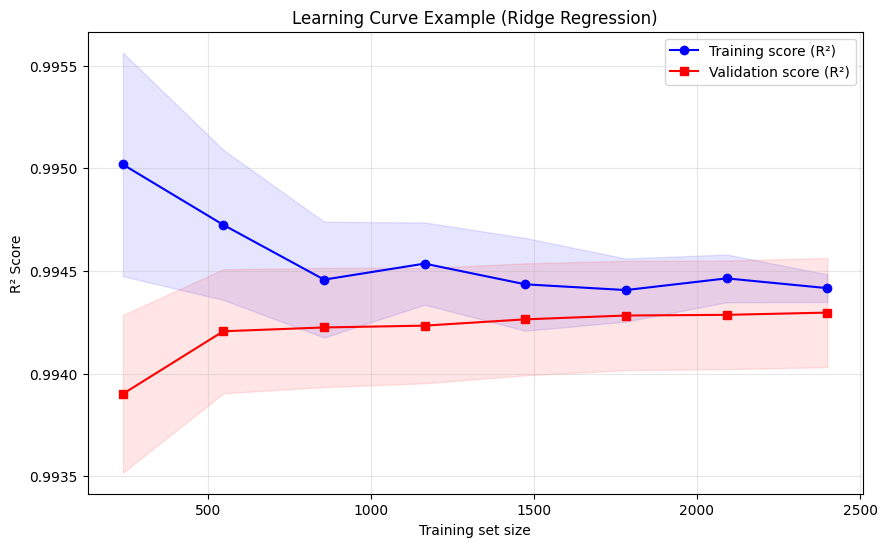

Learning Curve Results:
Training sizes: [ 240  548  857 1165 1474 1782 2091 2400]
Training R² scores: [0.995 0.995 0.994 0.995 0.994 0.994 0.994 0.994]
Validation R² scores: [0.994 0.994 0.994 0.994 0.994 0.994 0.994 0.994]
Final gap between training and validation: 0.000


In [3]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import learning_curve, KFold
from sklearn.linear_model import Ridge

X, y = make_regression(n_samples=3000, n_features=20, noise=15.0, random_state=42)
estimator = Ridge(alpha=1.0, random_state=42)

# Setting up cross-validation and generate learning curves
cv = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, valid_scores = learning_curve(
    estimator, X, y, cv=cv, scoring="r2", 
    train_sizes=np.linspace(0.1, 1.0, 8), 
    n_jobs=None, shuffle=True, random_state=42
)

# Calculating mean scores for plotting
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)

# learning curve plot
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="red")
plt.plot(train_sizes, train_mean, marker="o", label="Training score (R²)", color="blue")
plt.plot(train_sizes, valid_mean, marker="s", label="Validation score (R²)", color="red")
plt.xlabel("Training set size")
plt.ylabel("R² Score")
plt.title("Learning Curve Example (Ridge Regression)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Learning Curve Results:")
print("Training sizes:", train_sizes.astype(int))
print("Training R² scores:", np.round(train_mean, 3))
print("Validation R² scores:", np.round(valid_mean, 3))
print(f"Final gap between training and validation: {train_mean[-1] - valid_mean[-1]:.3f}")

### Learning Curves Interpretation and Addressing Model Issues

**Understanding Learning Curves:** Learning curves are plots that show how a model's performance changes as the training set size increases, displaying both training and validation scores. They help us understand whether our model is learning effectively and whether we have enough data. In the Ridge regression example above, we can observe how the R² scores evolve as more training data becomes available.

**Signs of Underfitting:** Underfitting appears in learning curves when both training and validation scores are low and converge to a poor performance level, with little gap between them. This indicates that the model is too simple to capture the underlying patterns in the data, regardless of how much training data is provided. To address underfitting, I would: increase model complexity by using more features or polynomial features, reduce regularization strength (lower alpha in Ridge regression), try more complex algorithms like Random Forest or Gradient Boosting, or add feature engineering to create more informative variables.

**Signs of Overfitting:** Overfitting manifests in learning curves as a large gap between training and validation scores, where training performance is significantly higher than validation performance. The training score may be very high while validation score plateaus at a lower level or even decreases. To address overfitting, I would: increase regularization strength (higher alpha in Ridge regression), collect more training data if possible, reduce model complexity by feature selection or simpler algorithms, use cross-validation for hyperparameter tuning, apply early stopping in iterative algorithms, or use ensemble methods that naturally reduce overfitting through averaging.

## Exercise 4: Impact of Class Imbalance on Model Evaluation



In [4]:

from collections import Counter
import numpy as np

# Simulating rare disease dataset with 2% positive cases
y = np.array([1]*20 + [0]*980)  # 2 percent positives
counter = Counter(y)
majority_class = counter.most_common(1)[0][0]
baseline_accuracy = (y == majority_class).mean()

print("Rare Disease Dataset Analysis:")
print("="*40)
print("Class distribution:", dict(counter))
print(f"Total samples: {len(y)}")
print(f"Positive cases (disease): {counter[1]} ({counter[1]/len(y)*100:.1f}%)")
print(f"Negative cases (healthy): {counter[0]} ({counter[0]/len(y)*100:.1f}%)")
print(f"Majority class: {majority_class} ({'Healthy' if majority_class == 0 else 'Disease'})")
print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print("\nWhy this accuracy is misleading:")
print("• A classifier that predicts 'healthy' for everyone achieves 98% accuracy")
print("• But it fails to identify ANY disease cases (100% false negatives)")
print("• This high accuracy masks complete failure at the primary objective")
print("• Such a model has zero clinical value despite impressive accuracy numbers")

Rare Disease Dataset Analysis:
Class distribution: {np.int64(1): 20, np.int64(0): 980}
Total samples: 1000
Positive cases (disease): 20 (2.0%)
Negative cases (healthy): 980 (98.0%)
Majority class: 0 (Healthy)
Majority-class baseline accuracy: 0.9800 (98.0%)

Why this accuracy is misleading:
• A classifier that predicts 'healthy' for everyone achieves 98% accuracy
• But it fails to identify ANY disease cases (100% false negatives)
• This high accuracy masks complete failure at the primary objective
• Such a model has zero clinical value despite impressive accuracy numbers


### Complete Analysis: Class Imbalance in Rare Disease Detection

**Why Accuracy is Misleading in Imbalanced Datasets:** In a rare disease detection scenario where only 2% of cases are positive, accuracy becomes a fundamentally flawed metric because a naive classifier can achieve 98% accuracy by simply predicting "no disease" for every patient. This creates a dangerous illusion of excellent performance while the model completely fails at its primary objective of identifying sick patients. The high accuracy is driven entirely by the overwhelming number of healthy patients (true negatives), masking the fact that the model provides zero value in detecting the rare disease it was designed to identify. Healthcare providers relying on such misleading accuracy metrics could deploy a completely useless diagnostic tool, leading to systematic failure in patient care.

**Critical Importance of Precision and Recall:** In rare disease detection, precision measures how many of the patients flagged as having the disease actually have it, which is crucial for avoiding unnecessary anxiety, invasive procedures, and healthcare costs from false alarms. Recall measures how many of the actual disease cases are successfully identified, which is even more critical because missing a true case can be life-threatening, leading to delayed treatment and poor patient outcomes. These metrics reflect the two fundamental types of errors: precision addresses the harm from false positives (healthy patients subjected to unnecessary follow-up), while recall addresses the potentially fatal consequences of false negatives (sick patients who remain undiagnosed). In rare disease contexts, recall is typically prioritized because the cost of missing a case far exceeds the cost of additional testing.

**Comprehensive Strategies for Imbalanced Dataset Evaluation and Improvement:** To effectively handle class imbalance, I would implement multiple complementary strategies: use stratified train-test splits to maintain class proportions across datasets; employ appropriate evaluation metrics like AUC-ROC, AUC-PR (precision-recall), F1-score, and balanced accuracy instead of simple accuracy; apply class weighting in algorithms to penalize misclassification of minority class more heavily; implement resampling techniques such as SMOTE for oversampling the minority class or random undersampling of the majority class; use ensemble methods that naturally handle imbalance better; calibrate probability outputs to ensure reliable confidence scores; cross-validate using stratified k-fold to ensure consistent evaluation; and consider cost-sensitive learning where the cost of false negatives is explicitly higher than false positives, allowing the model to optimize for the specific clinical requirements of rare disease detection.

## Exercise 5: Role of Threshold Tuning in Classification Models

### Instructions
You are evaluating a binary classification model that predicts whether a bank's client will default on a loan. The model outputs a probability score between 0 and 1.

1. Describe how changing the threshold for classifying a positive case (default) from 0.5 to 0.7 might affect the model's precision and recall.
2. Discuss the potential consequences of setting the threshold too high or too low in the context of loan default prediction.
3. Explain how ROC (Receiver Operating Characteristic) curves and AUC (Area Under the Curve) can assist in finding the optimal threshold.

### Guidance
You will write one paragraph that explains how increasing the threshold generally increases precision and decreases recall, while decreasing the threshold usually does the opposite.
You will then write one paragraph that explains practical consequences of the threshold choice in loan default prediction for both false positives and false negatives.
You will finally run the prefilled code to see how precision and recall change with the threshold and how the ROC curve and AUC summarize trade-offs.

### Threshold Impact Analysis

**Effect of Changing Threshold from 0.5 to 0.7:** When increasing the classification threshold from 0.5 to 0.7, the model becomes more conservative in predicting loan defaults, requiring higher confidence (probability ≥ 0.7) before classifying a customer as likely to default. This increase in threshold typically leads to higher precision because the model only flags cases it is very confident about, reducing false positives (good customers incorrectly labeled as risky). However, this same conservatism decreases recall because the model will miss some actual defaulters who have probability scores between 0.5 and 0.7, increasing false negatives. Conversely, lowering the threshold makes the model more aggressive in flagging potential defaults, capturing more actual defaulters (higher recall) but also incorrectly flagging more good customers (lower precision).

**Business Consequences of Threshold Selection in Loan Default Prediction:** Setting the threshold too high (overly conservative) results in many actual defaulters being approved for loans, leading to significant financial losses for the bank when these customers fail to repay. However, it also means fewer good customers are rejected, maintaining customer satisfaction and loan volume. Setting the threshold too low (overly aggressive) causes the bank to reject many creditworthy customers, resulting in lost revenue from foregone loans and potential damage to customer relationships and market share. The optimal threshold must balance these competing costs: the financial impact of loan defaults versus the opportunity cost of rejected applications, considering factors like loan amounts, profit margins, market competition, and the bank's risk tolerance and regulatory requirements.

Loan Default Prediction - Threshold Analysis
Threshold  Precision  Recall   F1-Score
----------------------------------------
      0.1      0.400   1.000     0.571
      0.2      0.522   1.000     0.686
      0.3      0.706   1.000     0.828
      0.4      0.857   1.000     0.923
      0.5      1.000   1.000     1.000
      0.6      1.000   1.000     1.000
      0.7      1.000   0.917     0.957
      0.8      1.000   0.583     0.737
      0.9      1.000   0.167     0.286


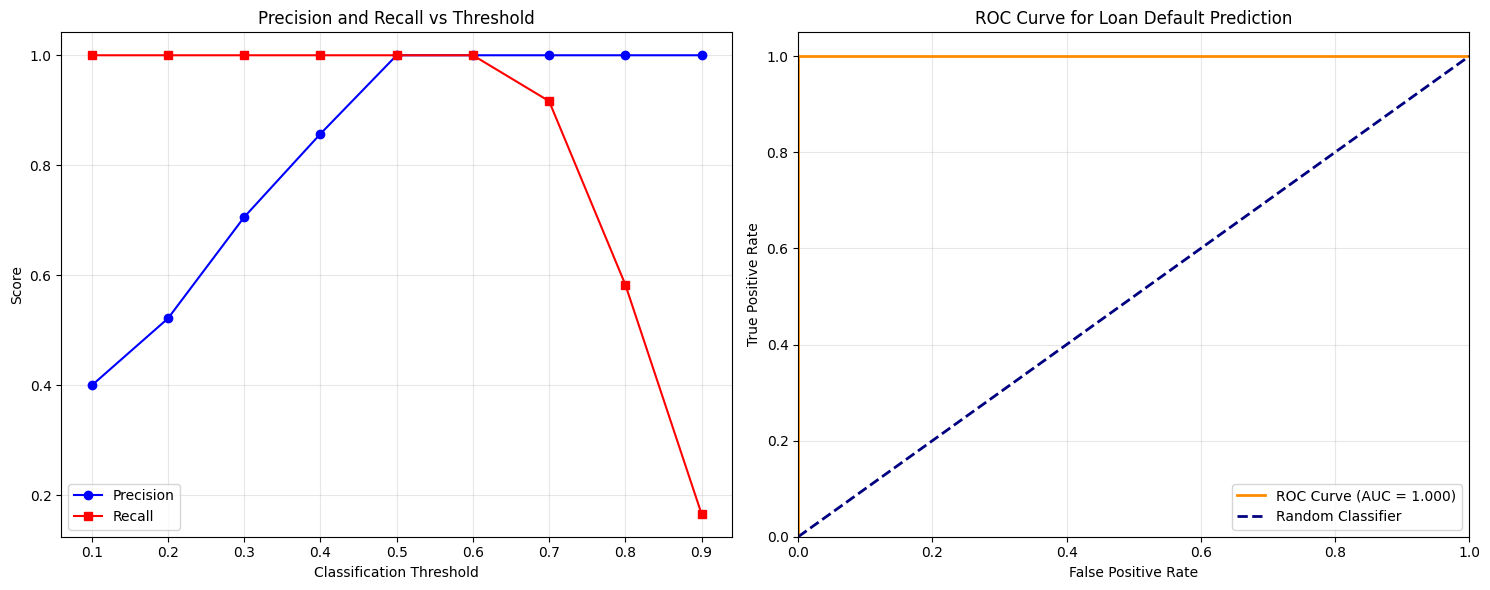


ROC AUC Score: 1.000
Model discrimination ability: Excellent


In [5]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, roc_curve, auc, f1_score

#  loan default prediction data
# 0 = No default, 1 = Default
y_true = np.array([0,1,0,1,0,1,0,0,1,0,1,0,0,1,0,0,1,0,1,0,1,0,0,1,0,1,0,0,1,0])
y_pred_proba = np.array([0.10,0.82,0.12,0.65,0.28,0.73,0.33,0.21,0.88,0.19,0.77,0.40,0.27,0.91,0.31,0.18,0.79,0.29,0.84,0.22,0.86,0.15,0.35,0.93,0.25,0.75,0.42,0.13,0.89,0.17])

print("Loan Default Prediction - Threshold Analysis")
print("="*50)

# Analyzing different thresholds
thresholds = np.linspace(0.1, 0.9, 9)
results = []

print("Threshold  Precision  Recall   F1-Score")
print("-" * 40)
for t in thresholds:
    y_pred = (y_pred_proba >= t).astype(int)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    results.append((t, prec, rec, f1))
    print(f"{t:>9.1f}  {prec:>9.3f}  {rec:>6.3f}  {f1:>8.3f}")

#  ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot for Precision-Recall vs Threshold
thresholds_array = np.array([r[0] for r in results])
precision_array = np.array([r[1] for r in results])
recall_array = np.array([r[2] for r in results])

ax1.plot(thresholds_array, precision_array, marker='o', label='Precision', color='blue')
ax1.plot(thresholds_array, recall_array, marker='s', label='Recall', color='red')
ax1.set_xlabel('Classification Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision and Recall vs Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot for ROC Curve
ax2.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', color='darkorange', lw=2)
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve for Loan Default Prediction')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nROC AUC Score: {roc_auc:.3f}")
print(f"Model discrimination ability: {'Excellent' if roc_auc > 0.9 else 'Good' if roc_auc > 0.8 else 'Fair' if roc_auc > 0.7 else 'Poor'}")

### ROC Curves and AUC for Optimal Threshold Selection

**How ROC Curves and AUC Assist in Threshold Optimization:** ROC (Receiver Operating Characteristic) curves plot the True Positive Rate (recall) against the False Positive Rate (1-specificity) across all possible classification thresholds, providing a comprehensive view of the model's discriminative performance at every threshold level. The AUC (Area Under the Curve) summarizes this performance into a single metric, where an AUC of 1.0 indicates perfect discrimination and 0.5 represents random guessing. ROC curves help identify the optimal threshold by allowing us to visualize the trade-off between sensitivity (catching actual defaulters) and specificity (avoiding false alarms), enabling stakeholders to choose a threshold that aligns with their business priorities. The curve's shape reveals whether the model has good discriminative power across all threshold ranges, while points closer to the top-left corner represent thresholds with the best balance of high true positive rates and low false positive rates.

**Practical Application in Loan Default Prediction:** For loan default prediction, the ROC curve enables banks to make informed decisions about risk tolerance by showing exactly how many good customers will be rejected (false positive rate) for each level of default detection (true positive rate). A bank prioritizing risk minimization might choose a threshold near the top-left of the curve to maximize default detection even at the cost of rejecting more good customers, while a bank focused on customer acquisition might choose a threshold that minimizes false positives. The AUC score provides a threshold-independent measure of model quality, allowing comparison between different models before threshold selection, while the ROC curve itself guides the final threshold choice based on the specific business context and cost considerations of each type of classification error.

## Summary and Key Learnings

### Comprehensive Understanding Achieved

Through these five exercises, you have developed a deep understanding of advanced machine learning evaluation concepts:

**Exercise 1 - Confusion Matrix Mastery:** You learned to interpret True Positives, True Negatives, False Positives, and False Negatives in practical contexts, understand how different error types impact business objectives, and calculate essential metrics including Accuracy, Precision, Recall, and F1-Score from confusion matrix values.

**Exercise 2 - Metric Trade-offs in Critical Applications:** You explored why different metrics are prioritized in different scenarios, particularly understanding why recall is crucial in medical diagnosis (missing diseases is dangerous) while precision becomes important when follow-up procedures are invasive or expensive.

**Exercise 3 - Cross-Validation and Learning Curves:** You distinguished between K-Fold and Stratified K-Fold cross-validation, learned to interpret learning curves to identify underfitting and overfitting, and developed strategies to address each issue through model complexity adjustments and regularization.

**Exercise 4 - Class Imbalance Challenges:** You discovered why accuracy can be misleading in imbalanced datasets, understood the critical importance of precision and recall in rare event detection, and learned comprehensive strategies including resampling, class weighting, and appropriate metric selection.

**Exercise 5 - Threshold Optimization:** You explored how threshold selection affects precision and recall trade-offs, understood business implications of threshold choices in loan default prediction, and learned to use ROC curves and AUC for informed threshold selection.

### Strategic Framework for Model Evaluation

You now possess a comprehensive framework for evaluating machine learning models that considers:
- **Business Context:** Aligning evaluation metrics with real-world consequences
- **Data Characteristics:** Adapting evaluation strategies to handle class imbalance and data distribution
- **Stakeholder Needs:** Balancing different types of errors based on their relative costs
- **Model Behavior:** Using learning curves and cross-validation to ensure robust performance

This foundation will serve you well in tackling complex machine learning challenges across various domains, from healthcare and finance to technology and beyond.